# Week 5 — Relationship, Temporal and Channel Analysis

The objective of Week 5 was to investigate relationships between engagement variables and examine how trending activity varies across time and channels.

In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/INvideos.csv")

analysis = df.drop_duplicates().copy()

analysis["trending_date_parsed"] = pd.to_datetime(
    analysis["trending_date"],
    format="%y.%d.%m",
    errors="coerce"
)

analysis["publish_datetime"] = pd.to_datetime(
    analysis["publish_time"],
    errors="coerce",
    utc=True
)

with open("../data/IN_category_id.json", encoding="utf-8") as f:
    categories = json.load(f)

category_df = pd.DataFrame([
    {
        "category_id": int(item["id"]),
        "category_name": item["snippet"]["title"]
    }
    for item in categories["items"]
])

analysis = analysis.merge(
    category_df,
    on="category_id",
    how="left"
)

In [2]:
engagement = [
    "views",
    "likes",
    "dislikes",
    "comment_count"
]

correlation = analysis[engagement].corr()

correlation

,views,likes,dislikes,comment_count
views,1.000000,0.852704,0.551652,0.697749
likes,0.852704,1.000000,0.499926,0.792815
dislikes,0.551652,0.499926,1.000000,0.740269
comment_count,0.697749,0.792815,0.740269,1.000000


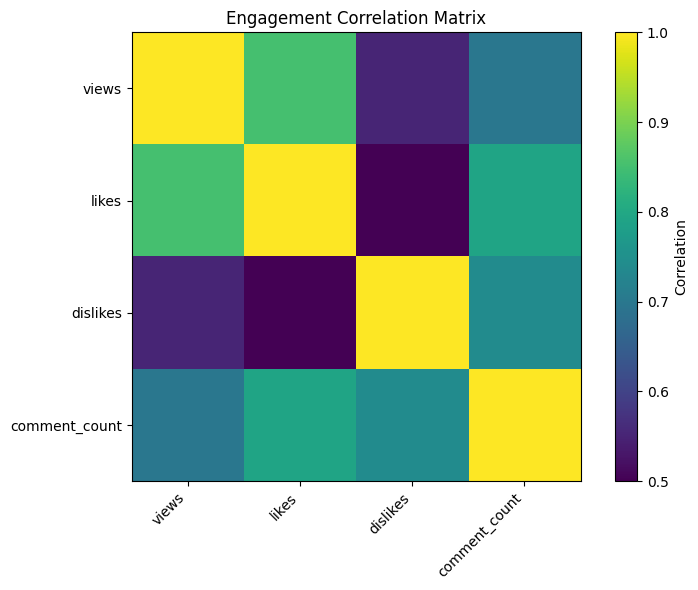

In [3]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="viridis")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.colorbar(label="Correlation")

plt.title("Engagement Correlation Matrix")

plt.tight_layout()
plt.show()

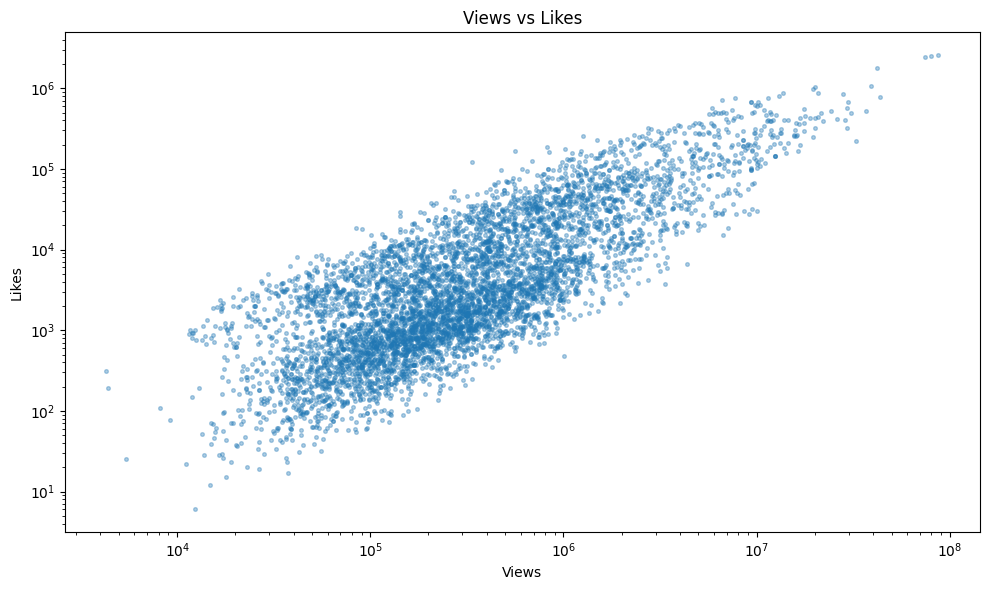

In [4]:
sample = analysis.sample(
    min(6000, len(analysis)),
    random_state=42
)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample["views"],
    sample["likes"],
    s=7,
    alpha=0.35
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Views vs Likes")

plt.tight_layout()
plt.show()

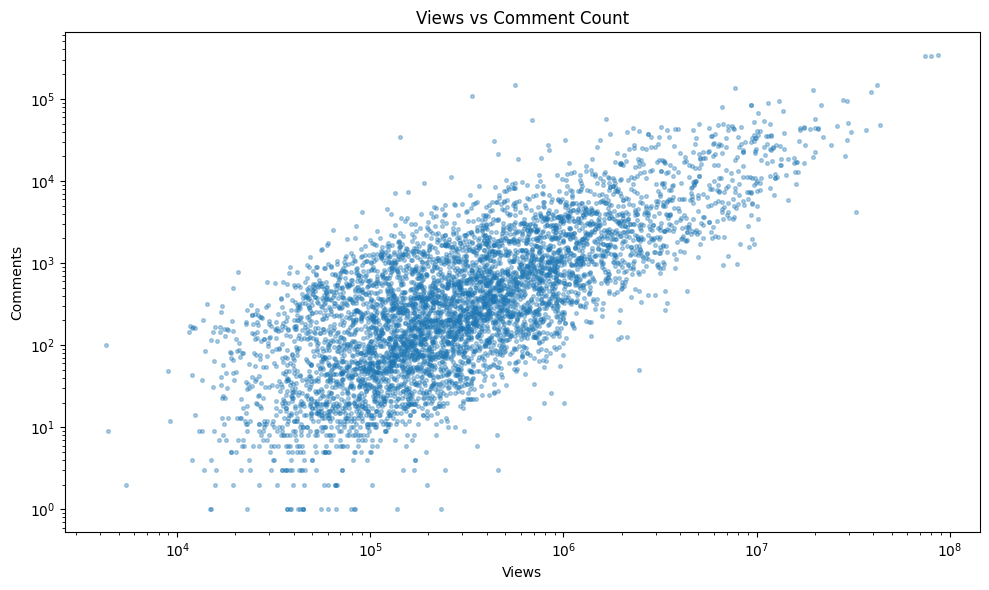

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(
    sample["views"],
    sample["comment_count"],
    s=7,
    alpha=0.35
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Views")
plt.ylabel("Comments")
plt.title("Views vs Comment Count")

plt.tight_layout()
plt.show()

In [6]:
daily = (
    analysis.groupby("trending_date_parsed")
    .agg(
        videos=("video_id", "count"),
        median_views=("views", "median"),
        median_likes=("likes", "median")
    )
    .sort_index()
)

daily.head()

,videos,median_views,median_likes
trending_date_parsed,,,
2017-11-14,200,117622.5,1096.0
2017-11-15,200,151069.0,1373.5
2017-11-16,200,168675.5,1417.5
2017-11-17,200,169136.0,1543.0
2017-11-18,200,186669.5,1819.0


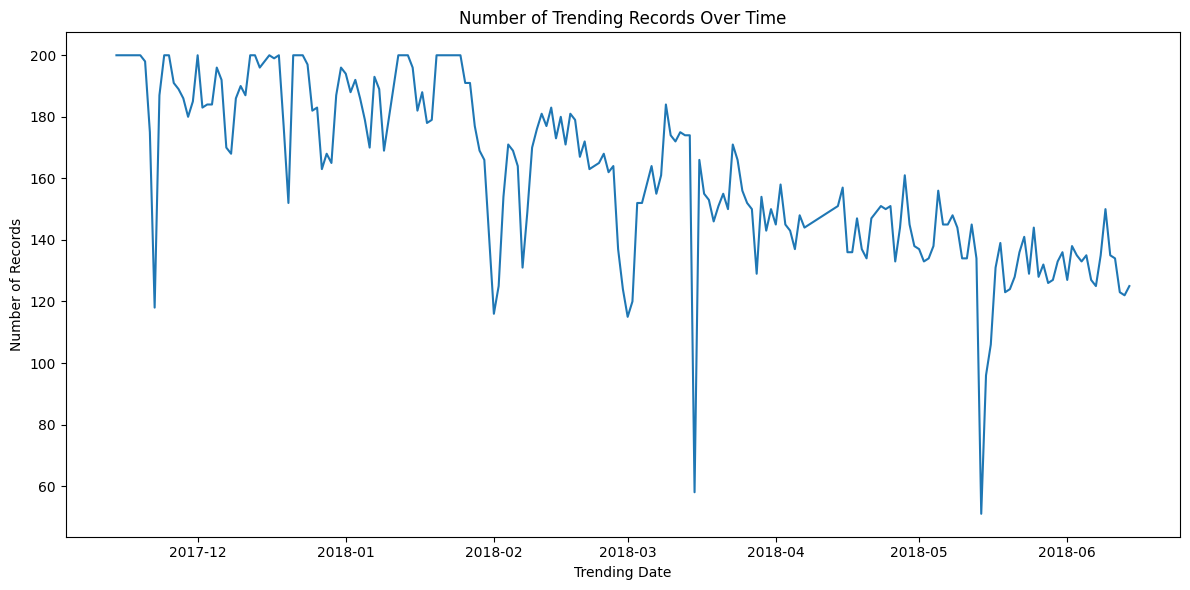

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily.index,
    daily["videos"]
)

plt.title("Number of Trending Records Over Time")
plt.xlabel("Trending Date")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

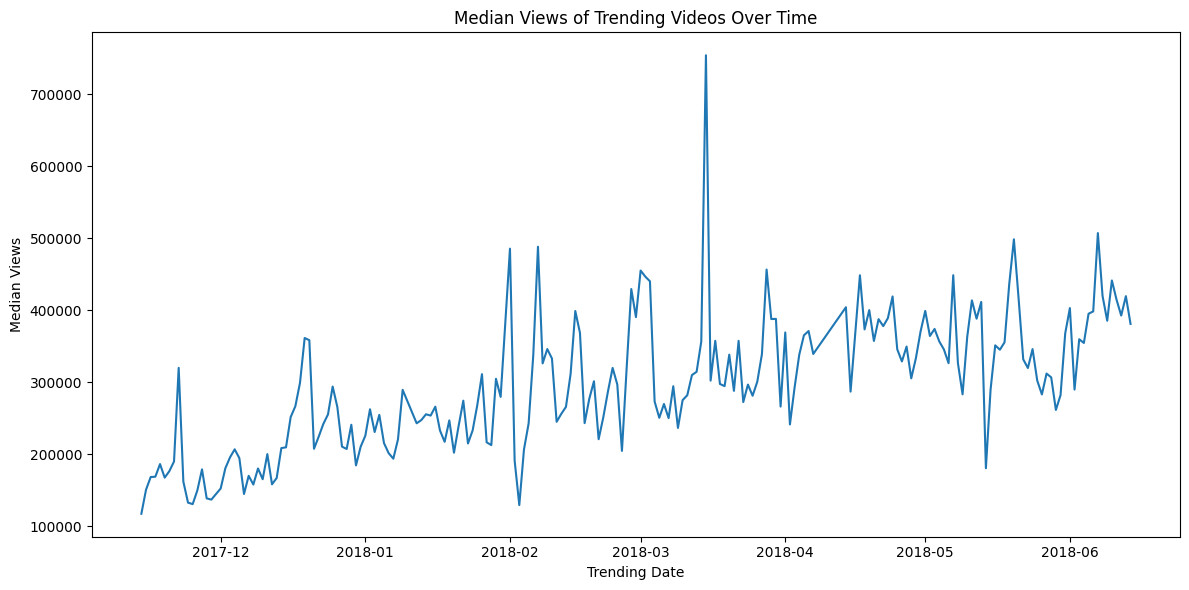

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily.index,
    daily["median_views"]
)

plt.title("Median Views of Trending Videos Over Time")
plt.xlabel("Trending Date")
plt.ylabel("Median Views")

plt.tight_layout()
plt.show()

In [9]:
channel_summary = (
    analysis.groupby("channel_title")
    .agg(
        videos=("video_id", "count"),
        median_views=("views", "median"),
        total_views=("views", "sum")
    )
    .sort_values("videos", ascending=False)
)

channel_summary.head(15)


,videos,median_views,total_views
channel_title,,,
VikatanTV,208,665398.0,151026885
SAB TV,206,276507.0,80287318
ETV Plus India,206,320455.5,95562261
etvteluguindia,205,209475.0,89450329
Flowers Comedy,202,592998.5,134339392
Study IQ education,202,52044.5,11422244
Tarang TV,199,85591.0,20019000
SET India,199,649790.0,191136460
Mazhavil Manorama,196,255161.0,62898862


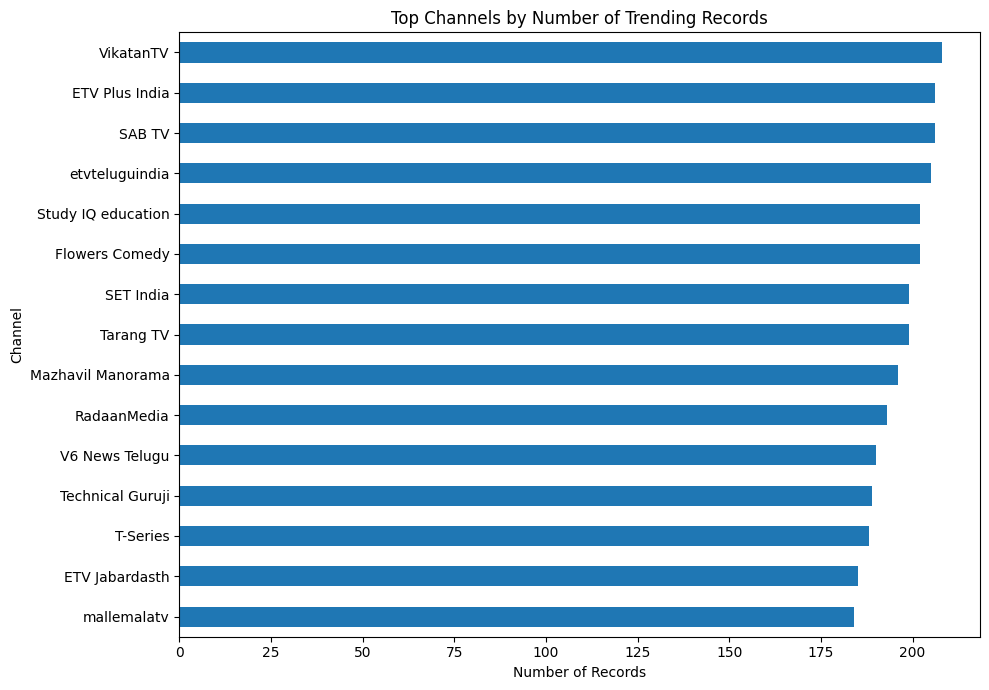

In [10]:
top_channels = channel_summary.head(15)

plt.figure(figsize=(10, 7))

top_channels["videos"].sort_values().plot(
    kind="barh"
)

plt.title("Top Channels by Number of Trending Records")
plt.xlabel("Number of Records")
plt.ylabel("Channel")

plt.tight_layout()
plt.show()

In [11]:
channel_views = (
    channel_summary[
        channel_summary["videos"] >= 20
    ]
    .sort_values("median_views", ascending=False)
    .head(10)
)

channel_views[["videos", "median_views", "total_views"]]

,videos,median_views,total_views
channel_title,,,
FoxStarHindi,44,27845047.5,982953616
Sony Pictures Entertainment,27,14528223.0,587519233
Disney•Pixar,21,14478580.0,309791867
Paramount Pictures,22,12625042.5,261179619
Dude Perfect,49,11150609.0,527111130
Universal Pictures,30,10542071.0,398364239
20th Century Fox,30,10163294.0,331073966
Warner Bros. Pictures,30,8933707.5,264047292
Tips Official,34,8786318.0,299296928


In [12]:
print("Dataset rows analysed:", len(analysis))
print("Views-Likes correlation:",
      round(analysis["views"].corr(analysis["likes"]), 3))

print("Views-Comments correlation:",
      round(analysis["views"].corr(analysis["comment_count"]), 3))

print("Trending period:",
      analysis["trending_date_parsed"].min().date(),
      "to",
      analysis["trending_date_parsed"].max().date())

Dataset rows analysed: 33089
Views-Likes correlation: 0.853
Views-Comments correlation: 0.698
Trending period: 2017-11-14 to 2018-06-14


## Week 5 Observations

Relationship analysis was used to examine associations between views and other engagement measures.

Temporal analysis was used to examine changes in the number of trending records and median views over the available period.

Channel-level analysis was used to identify channels with repeated appearances in the trending dataset while applying a minimum-record threshold when comparing channel performance.

Correlation results are interpreted as associations within the dataset and are not treated as evidence of causation.
